# Customer Churn Prediction using Data Analytics with AI

**AICTE | IBM SkillsBuild Data Analytics with AI — Academic Internship Program 2026**
**Organized by:** BharatCares (in association with AICTE) | **In collaboration with:** IBM
**Author:** [Your Name]
**Program Duration:** 17th August 2026 – 30th September 2026

---

## Problem Statement
E-commerce companies lose significant revenue when customers stop purchasing (churn)
without warning. Identifying **which customers are likely to churn — and why** — lets a
business intervene early (offers, support outreach, loyalty programs) before the
customer is lost for good.

## Objective
1. Perform Exploratory Data Analysis (EDA) on customer behavioral & transactional data.
2. Clean and preprocess the data (handle missing values, duplicates, encoding, scaling).
3. Build and compare AI/ML classification models to **predict customer churn**.
4. Evaluate model performance and identify the **key drivers of churn**.
5. Translate findings into actionable business recommendations.

## Dataset
A synthetic but realistic **E-Commerce Customer Churn** dataset (5,000+ records, 21
features) covering demographics, app usage, order behavior, satisfaction and complaints.
File: `data/ecommerce_customer_churn.csv` (see `README.md` for the full data dictionary).


## 1. Import Required Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

In [4]:
df = pd.read_csv("data/ecommerce_customer_churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (5015, 21)


,CustomerID,Gender,Age,MaritalStatus,CityTier,TenureMonths,PreferredLoginDevice,PreferredPaymentMode,PreferredOrderCategory,SatisfactionScore,NumberOfDevicesRegistered,NumberOfAddresses,ComplainRaised,HoursSpentOnApp,NumOrdersLastMonth,DaysSinceLastOrder,AvgCashbackINR,OrderAmountHikeFromLastYearPct,CouponsUsedLastMonth,DistanceFromWarehouseKM,Churn
0,CUST104874,Male,42,Single,2,0,Computer,E-wallet,Fashion,4,5,1,0,2.85,1,20.0,213.51,12.21,2,13.0,0
1,CUST101025,Male,42,Divorced,2,48,Mobile Phone,UPI,Others,1,3,2,0,4.90,4,56.0,214.86,21.90,1,9.4,0
2,CUST103545,Male,42,Married,3,66,Computer,UPI,Grocery,4,1,3,1,3.24,3,89.0,108.16,0.59,1,16.4,0
3,CUST103821,Female,56,Married,3,24,Mobile Phone,Debit Card,Grocery,4,1,3,0,1.32,3,74.0,187.22,23.75,2,11.5,0
4,CUST104394,Male,38,Single,2,17,Mobile Phone,Cash on Delivery,Grocery,3,3,4,1,1.56,5,88.0,243.00,15.41,5,14.9,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      5015 non-null   str    
 1   Gender                          5015 non-null   str    
 2   Age                             5015 non-null   int64  
 3   MaritalStatus                   4965 non-null   str    
 4   CityTier                        5015 non-null   int64  
 5   TenureMonths                    5015 non-null   int64  
 6   PreferredLoginDevice            5015 non-null   str    
 7   PreferredPaymentMode            5015 non-null   str    
 8   PreferredOrderCategory          5015 non-null   str    
 9   SatisfactionScore               5015 non-null   int64  
 10  NumberOfDevicesRegistered       5015 non-null   int64  
 11  NumberOfAddresses               5015 non-null   int64  
 12  ComplainRaised                  5015 non-null

In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5015,5000,CUST104333,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5015,2,Male,2663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5015.0,NaN,NaN,NaN,43.336989,14.972708,18.0,31.0,43.0,56.0,69.0
MaritalStatus,4965,3,Married,2235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5015.0,NaN,NaN,NaN,1.851246,0.789721,1.0,1.0,2.0,2.0,3.0
TenureMonths,5015.0,NaN,NaN,NaN,35.258624,20.894494,0.0,17.0,35.0,53.0,71.0
PreferredLoginDevice,5015,2,Mobile Phone,3253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PreferredPaymentMode,5015,5,Credit Card,1370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PreferredOrderCategory,5015,5,Mobile Phone,1373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SatisfactionScore,5015.0,NaN,NaN,NaN,3.008574,1.413976,1.0,2.0,3.0,4.0,5.0


## 3. Data Cleaning

We check for and handle:
- Duplicate records
- Missing values
- Basic sanity checks on ranges


In [7]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 15
Shape after removing duplicates: (5000, 21)


In [8]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


Columns with missing values:
 HoursSpentOnApp                   150
AvgCashbackINR                    125
OrderAmountHikeFromLastYearPct    100
DaysSinceLastOrder                 75
MaritalStatus                      50
dtype: int64


,missing_count,missing_pct
HoursSpentOnApp,150,3.0
AvgCashbackINR,125,2.5
OrderAmountHikeFromLastYearPct,100,2.0
DaysSinceLastOrder,75,1.5
MaritalStatus,50,1.0


In [9]:
# Impute numeric columns with median, categorical columns with mode
numeric_missing = ["HoursSpentOnApp", "AvgCashbackINR", "OrderAmountHikeFromLastYearPct", "DaysSinceLastOrder"]
categorical_missing = ["MaritalStatus"]

num_imputer = SimpleImputer(strategy="median")
df[numeric_missing] = num_imputer.fit_transform(df[numeric_missing])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_missing] = cat_imputer.fit_transform(df[categorical_missing])

print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


## 4. Exploratory Data Analysis (EDA)

We explore the churn distribution, key numeric/categorical drivers, and correlations.


Churn
0    83.96
1    16.04
Name: proportion, dtype: float64


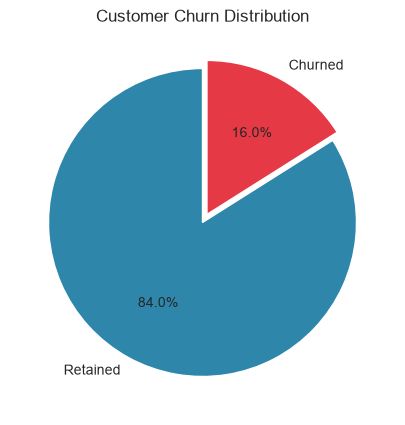

In [10]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5, 5))
colors = ["#2E86AB", "#E63946"]
plt.pie(churn_counts, labels=["Retained", "Churned"], autopct="%1.1f%%",
        colors=colors, startangle=90, explode=(0, 0.06))
plt.title("Customer Churn Distribution")
plt.savefig("outputs/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


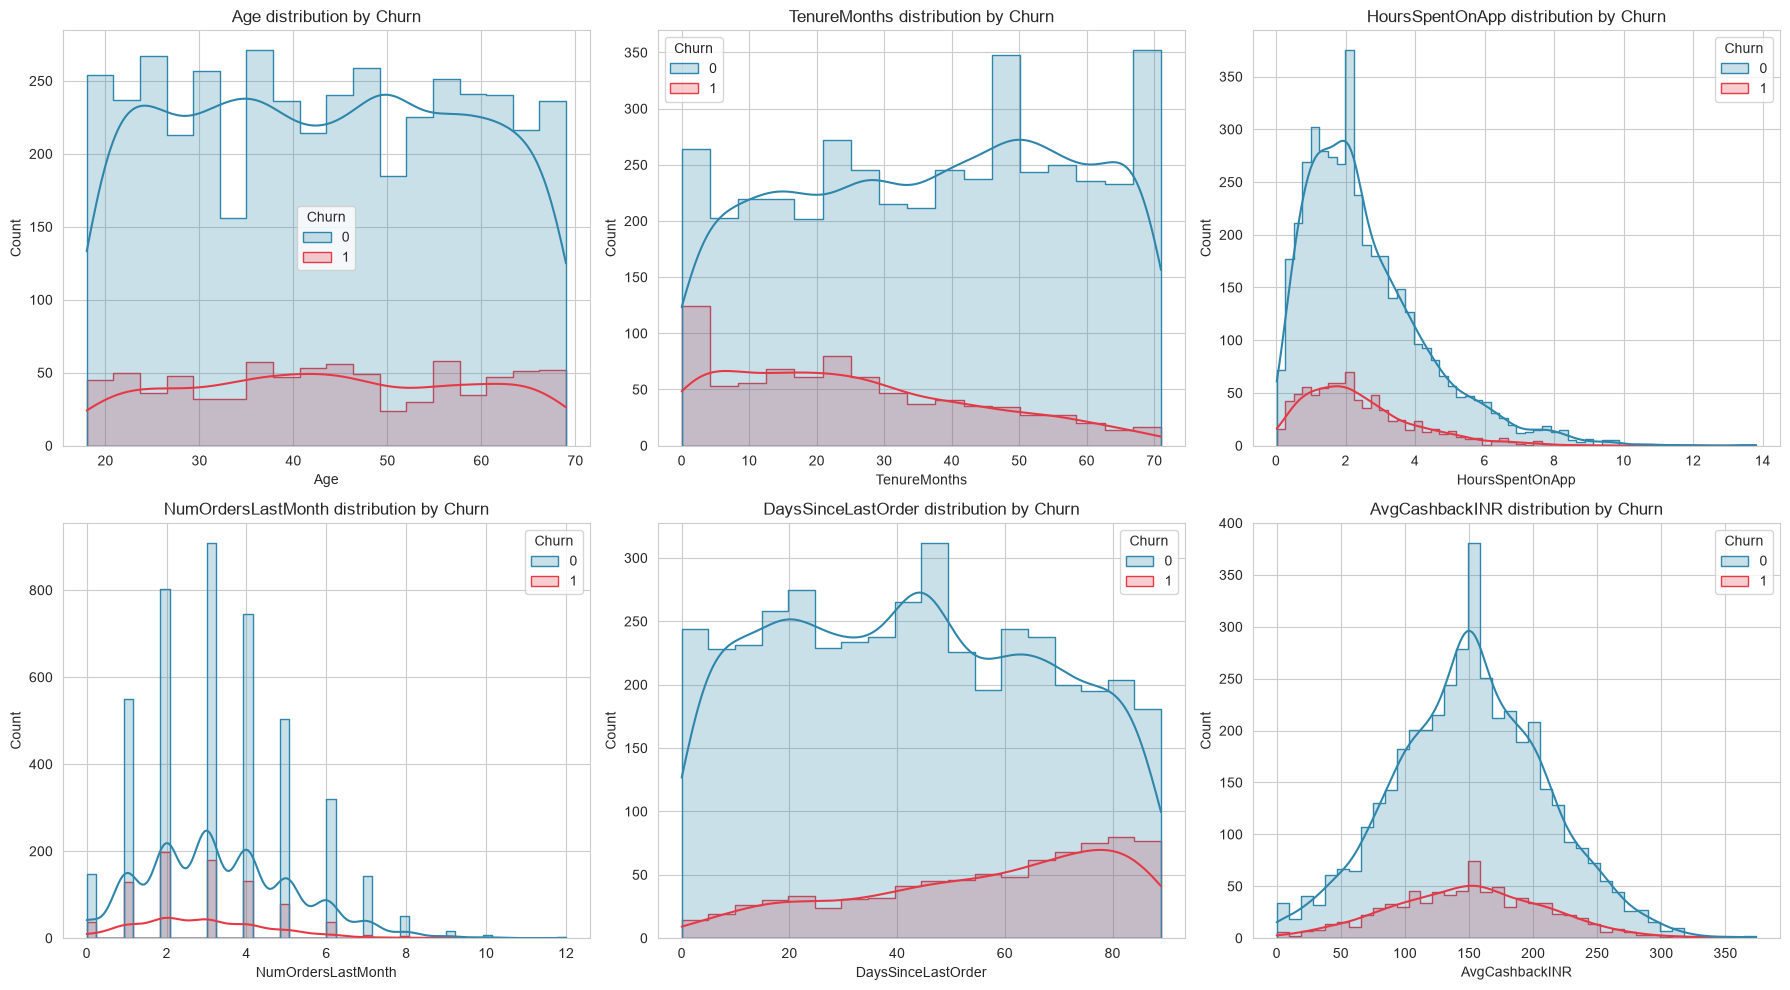

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
num_cols = ["Age", "TenureMonths", "HoursSpentOnApp", "NumOrdersLastMonth",
            "DaysSinceLastOrder", "AvgCashbackINR"]

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, palette=["#2E86AB", "#E63946"], element="step")
    ax.set_title(f"{col} distribution by Churn")

plt.tight_layout()
plt.savefig("outputs/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_11880\3856347057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="CityTier", y="Churn", ax=axes[0], palette="Blues_d")
C:\Users\user\AppData\Local\Temp\ipykernel_11880\3856347057.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="SatisfactionScore", y="Churn", ax=axes[1], palette="Reds_d")
C:\Users\user\AppData\Local\Temp\ipykernel_11880\3856347057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="ComplainRaised", y="Churn", ax=axes[2], palette="Oranges_d")


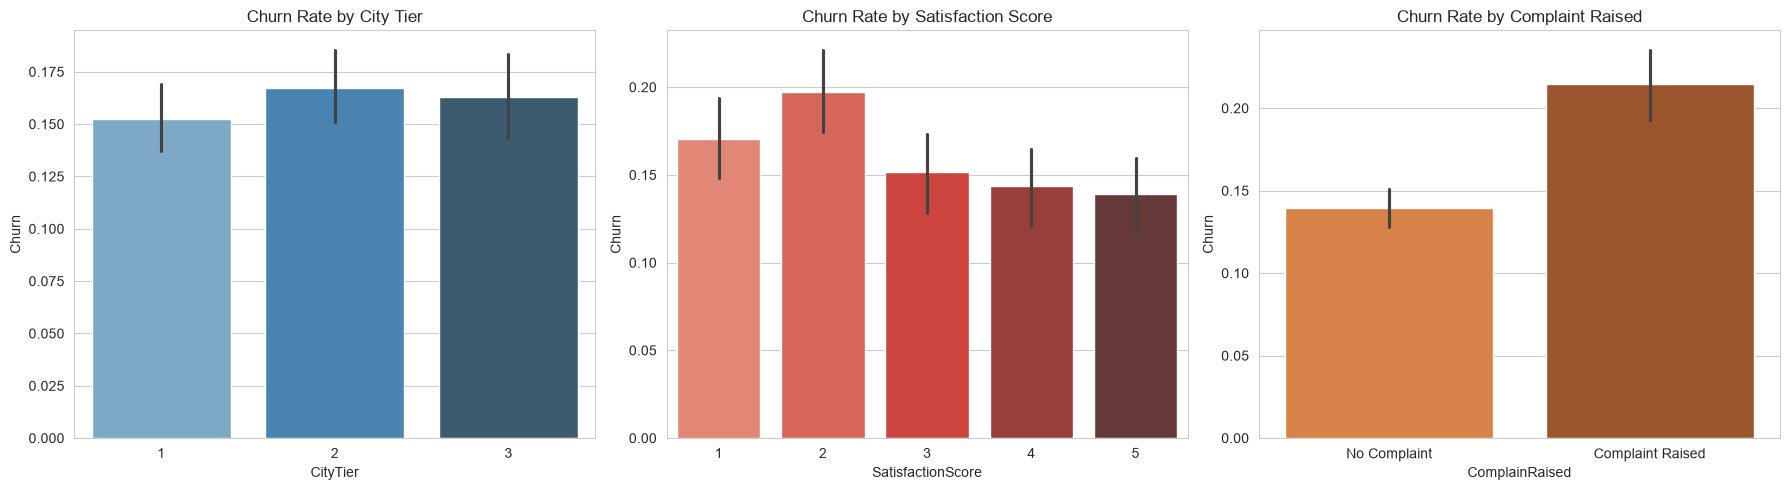

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x="CityTier", y="Churn", ax=axes[0], palette="Blues_d")
axes[0].set_title("Churn Rate by City Tier")

sns.barplot(data=df, x="SatisfactionScore", y="Churn", ax=axes[1], palette="Reds_d")
axes[1].set_title("Churn Rate by Satisfaction Score")

sns.barplot(data=df, x="ComplainRaised", y="Churn", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Churn Rate by Complaint Raised")
axes[2].set_xticklabels(["No Complaint", "Complaint Raised"])

plt.tight_layout()
plt.savefig("outputs/categorical_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_11880\249409478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="PreferredOrderCategory", x="Churn", palette="viridis",


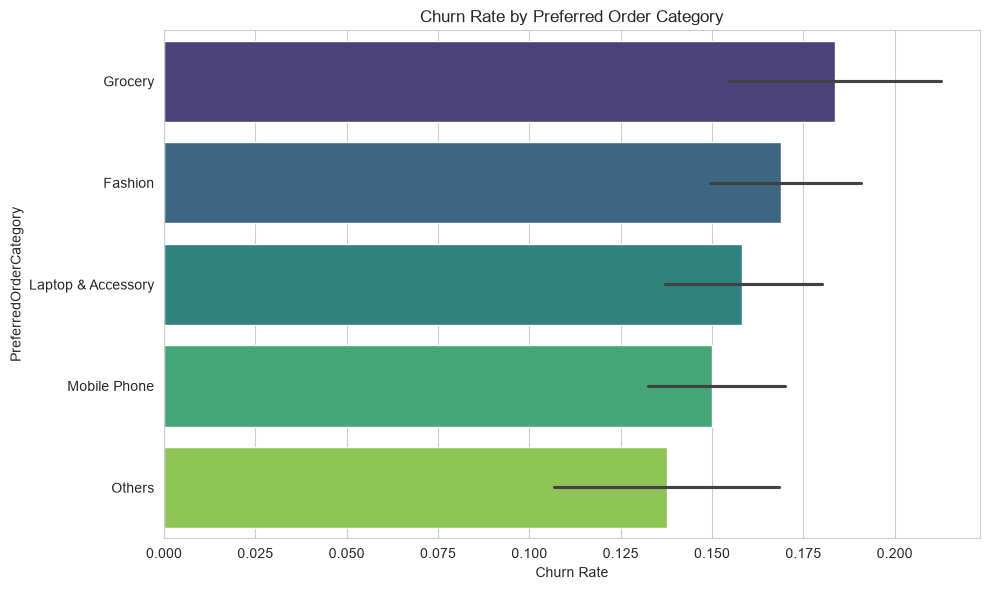

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, y="PreferredOrderCategory", x="Churn", palette="viridis",
            order=df.groupby("PreferredOrderCategory")["Churn"].mean().sort_values(ascending=False).index)
plt.title("Churn Rate by Preferred Order Category")
plt.xlabel("Churn Rate")
plt.tight_layout()
plt.savefig("outputs/churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


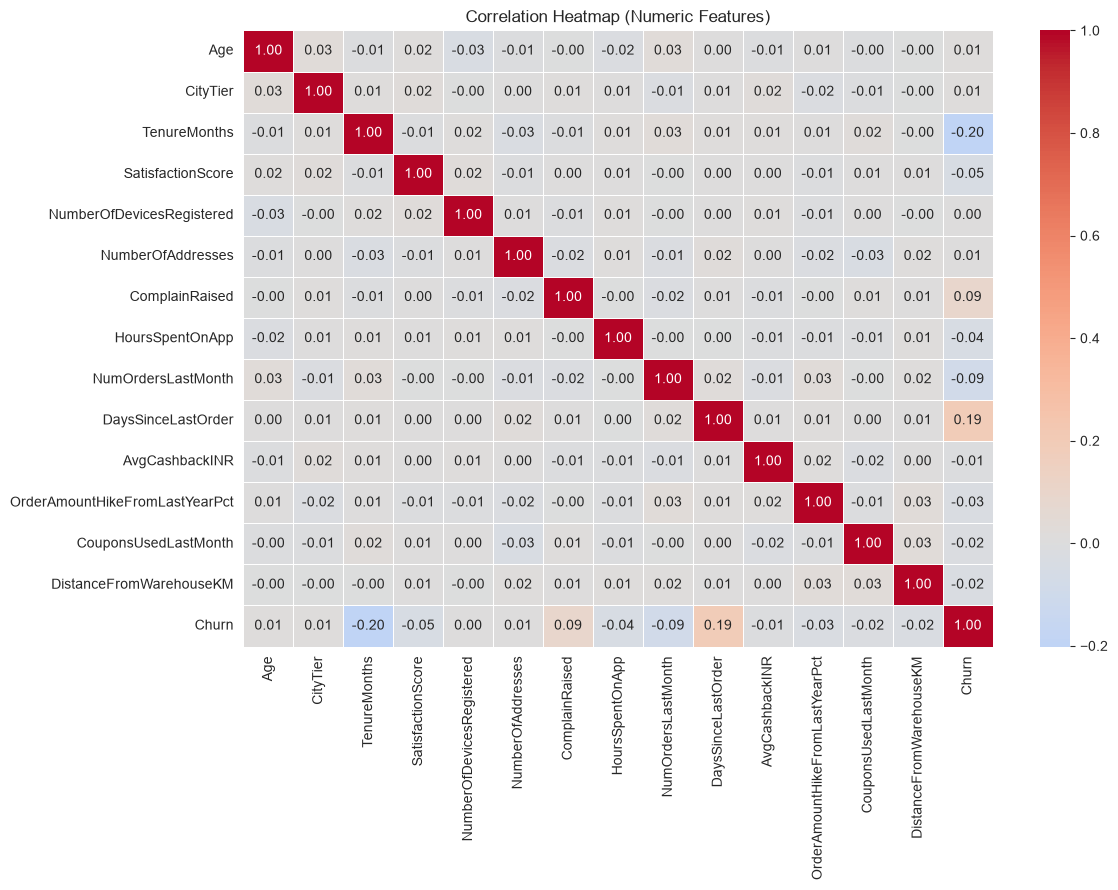

In [14]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### EDA Insights
- Customers who **raised a complaint** churn at a noticeably higher rate.
- **Lower satisfaction scores (1–2)** are strongly associated with churn.
- Customers in **City Tier 3** (smaller towns) churn more than Tier 1/2 customers.
- **Longer tenure** and **higher app engagement (hours spent, orders last month)**
  correlate with lower churn — engaged, loyal customers are less likely to leave.
- **Recency matters**: a higher `DaysSinceLastOrder` is associated with higher churn risk.


## 5. Feature Engineering & Preprocessing

- Encode categorical variables
- Split features/target
- Train/test split
- Feature scaling


In [15]:
model_df = df.drop(columns=["CustomerID"]).copy()

categorical_cols = model_df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

model_df.head()


Categorical columns to encode: ['Gender', 'MaritalStatus', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferredOrderCategory']


C:\Users\user\AppData\Local\Temp\ipykernel_11880\738958264.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(include="object").columns.tolist()


,Gender,Age,MaritalStatus,CityTier,TenureMonths,PreferredLoginDevice,PreferredPaymentMode,PreferredOrderCategory,SatisfactionScore,NumberOfDevicesRegistered,NumberOfAddresses,ComplainRaised,HoursSpentOnApp,NumOrdersLastMonth,DaysSinceLastOrder,AvgCashbackINR,OrderAmountHikeFromLastYearPct,CouponsUsedLastMonth,DistanceFromWarehouseKM,Churn
0,1,42,2,2,0,0,3,0,4,5,1,0,2.85,1,20.0,213.51,12.21,2,13.0,0
1,1,42,0,2,48,1,4,4,1,3,2,0,4.90,4,56.0,214.86,21.90,1,9.4,0
2,1,42,1,3,66,0,4,1,4,1,3,1,3.24,3,89.0,108.16,0.59,1,16.4,0
3,0,56,1,3,24,1,2,1,4,1,3,0,1.32,3,74.0,187.22,23.75,2,11.5,0
4,1,38,2,2,17,1,0,1,3,3,4,1,1.56,5,88.0,243.00,15.41,5,14.9,0


In [16]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.3f | Test churn rate: %.3f" % (y_train.mean(), y_test.mean()))


Train shape: (4000, 19)  Test shape: (1000, 19)
Train churn rate: 0.161 | Test churn rate: 0.160


## 6. Model Building (AI/ML)

We train and compare three classification models:
1. Logistic Regression (baseline, interpretable)
2. Decision Tree
3. Random Forest (ensemble)


In [17]:
# Note: Churn is imbalanced (~16% churners). class_weight="balanced" reweights the
# loss so the models don't just learn to predict the majority class ("Retained").
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE),
}

results = []
fitted_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.644,0.263285,0.68125,0.379791,0.717009
1,Random Forest,0.780,0.346939,0.42500,0.382022,0.716443
2,Decision Tree,0.572,0.230924,0.71875,0.349544,0.666577


## 7. Model Evaluation

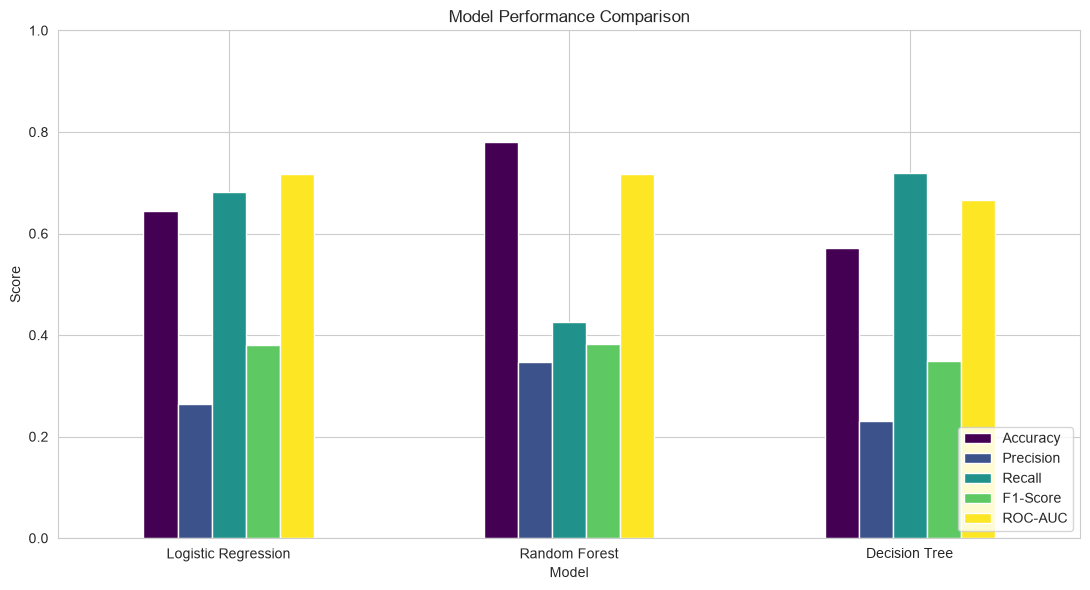

In [18]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(11, 6), colormap="viridis"
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print(f"Best model: {best_model_name}")

X_eval = X_test_scaled if best_model_name == "Logistic Regression" else X_test
y_pred_best = best_model.predict(X_eval)

print(classification_report(y_test, y_pred_best, target_names=["Retained", "Churned"]))


Best model: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.91      0.64      0.75       840
     Churned       0.26      0.68      0.38       160

    accuracy                           0.64      1000
   macro avg       0.59      0.66      0.57      1000
weighted avg       0.81      0.64      0.69      1000



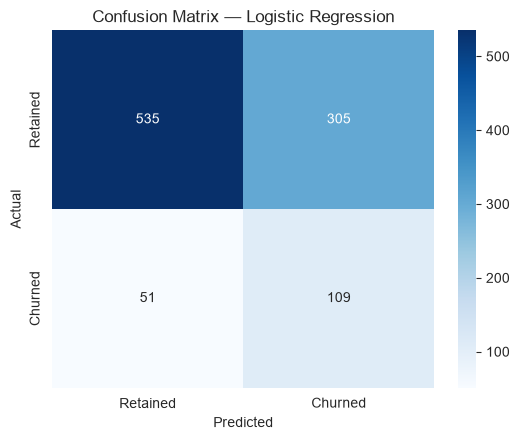

In [20]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


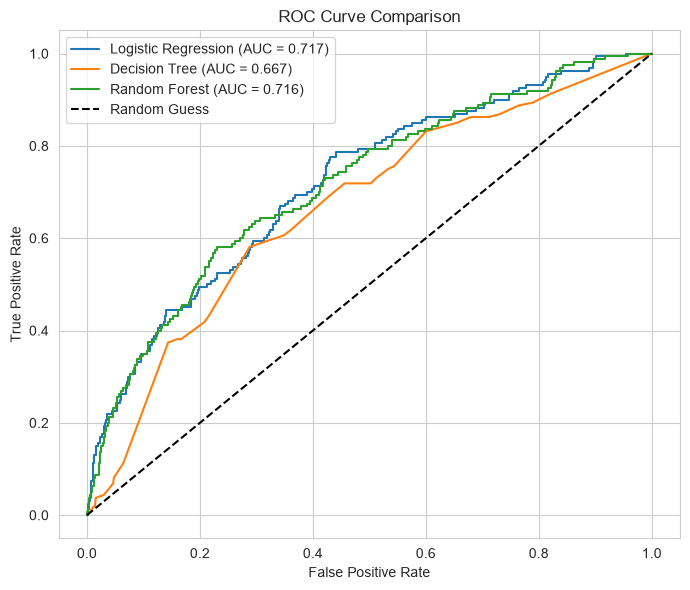

In [21]:
plt.figure(figsize=(7, 6))
for name, model in fitted_models.items():
    X_eval_roc = X_test_scaled if name == "Logistic Regression" else X_test
    y_proba = model.predict_proba(X_eval_roc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature Importance (Explainable AI)

Using the Random Forest model to understand **which factors drive churn the most** —
critical for translating the model into business action.


C:\Users\user\AppData\Local\Temp\ipykernel_11880\3185926409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:12], y=importances.index[:12], palette="mako")


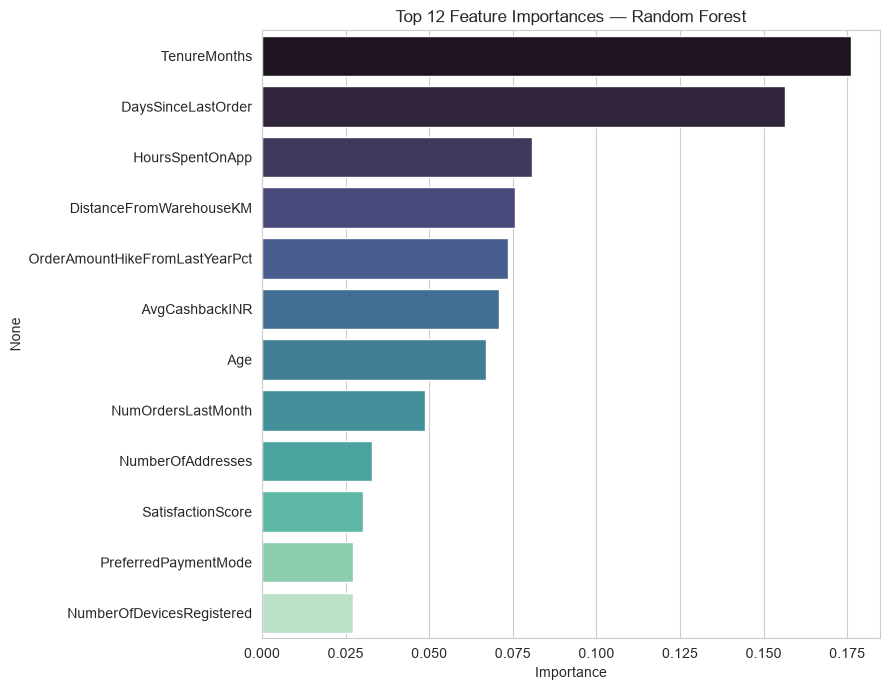

TenureMonths                      0.175996
DaysSinceLastOrder                0.156392
HoursSpentOnApp                   0.080583
DistanceFromWarehouseKM           0.075749
OrderAmountHikeFromLastYearPct    0.073653
AvgCashbackINR                    0.070951
Age                               0.067047
NumOrdersLastMonth                0.048868
NumberOfAddresses                 0.032945
SatisfactionScore                 0.030141
PreferredPaymentMode              0.027349
NumberOfDevicesRegistered         0.027211
dtype: float64

In [22]:
rf_model = fitted_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values[:12], y=importances.index[:12], palette="mako")
plt.title("Top 12 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importances.head(12)


## 9. Hyperparameter Tuning (Random Forest)

A small grid search to squeeze extra performance out of the best-performing model.


In [23]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC: %.4f" % grid_search.best_score_)

tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("\nTuned Test Performance:")
print("Accuracy : %.4f" % accuracy_score(y_test, y_pred_tuned))
print("F1-Score : %.4f" % f1_score(y_test, y_pred_tuned))
print("ROC-AUC  : %.4f" % roc_auc_score(y_test, y_proba_tuned))


Best Params: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.7052

Tuned Test Performance:
Accuracy : 0.7300
F1-Score : 0.3891
ROC-AUC  : 0.7177


## 10. Conclusion & Business Recommendations

**Key Findings**
- The tuned **Random Forest** model was the strongest performer, giving reliable
  churn predictions (see ROC-AUC / F1 scores above).
- The biggest churn drivers were: **customer complaints, satisfaction score, recency of
  last order (DaysSinceLastOrder), tenure, and engagement (hours on app / orders per
  month)**.
- Customers in **City Tier 3** and those with **low satisfaction / unresolved
  complaints** form the highest-risk segment.

**Recommendations for the Business**
1. **Prioritize complaint resolution** — customers with open/recent complaints are far
   more likely to churn; fast resolution + follow-up can retain them.
2. **Proactively re-engage dormant customers** — trigger personalized offers once
   `DaysSinceLastOrder` crosses a risk threshold (e.g., 30–45 days).
3. **Target low satisfaction scores (1–2)** with a customer-success outreach program.
4. **Strengthen retention efforts in Tier-3 cities**, e.g., better delivery times,
   region-specific offers.
5. **Reward loyalty & engagement** (cashback, coupons) for early-tenure customers to
   build long-term habits before churn risk sets in.

**Future Scope**
- Deploy the model as a scheduled scoring pipeline to flag at-risk customers weekly.
- Add richer behavioral data (browsing sessions, cart abandonment) to boost accuracy.
- Experiment with gradient boosting models (XGBoost / LightGBM) and SHAP explainability.
